# Невронна Мрежа за Предсказване на Текучеството

Този модел има за цел да подобри резултатите от базовия Decision Tree модел, като използва възможностите на Deep Learning за откриване на нелинейни зависимости.

**Основни компоненти:**
1.  **Архитектура:** Feed-Forward Neural Network (MLP) с няколко скрити слоя.
2.  **Справяне с дисбаланса:** Използване на `class_weight` за наказание на грешките при малцинствения клас.
3.  **Регуляризация:** `Dropout` и `EarlyStopping` за предотвратяване на преобучаване.
4.  **Оценка:** Фокус върху Recall и F1-Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install tensorflow # Install TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.stats import skew
import joblib
import os

# Настройка на графиките
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Зареждане на Данните
Използваме подготвените данни от `DataPrep`.

In [2]:
# 1. Зареждане на Оригиналните Данни
possible_paths = [
    '../../dataset/Extended_Employee_Performance_and_Productivity_Data.csv',
    '../../../dataset/Extended_Employee_Performance_and_Productivity_Data.csv',
    '/content/drive/MyDrive/2526-dzi-ai-ATApostolov21/data/Extended_Employee_Performance_and_Productivity_Data.csv',
    'dataset/Extended_Employee_Performance_and_Productivity_Data.csv',
    '/content/drive/MyDrive/2526-dzi-ai-ATApostolov21/Dataset/Extended_Employee_Performance_and_Productivity_Data.csv' # Updated path
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break
    # Check relative from notebook loc
    rel_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), path)
    if os.path.exists(rel_path):
         data_path = rel_path
         break

if data_path is None:
    # Try finding it relative to CWD if script is run from project root
    if os.path.exists('dataset/Extended_Employee_Performance_and_Productivity_Data.csv'):
        data_path = 'dataset/Extended_Employee_Performance_and_Productivity_Data.csv'
    elif os.path.exists('data/Extended_Employee_Performance_and_Productivity_Data.csv'):
        data_path = 'data/Extended_Employee_Performance_and_Productivity_Data.csv'

if data_path is None:
    print("WARNING: Data file not found automatically. Please verify path.")
    # Set a default to allow code inspection
    data_path = 'dataset/Extended_Employee_Performance_and_Productivity_Data.csv'

print(f"Зареждане на данни от: {data_path}")
try:
    df = pd.read_csv(data_path)
except:
    print("Error reading CSV. Check path.")
    # Create dummy df to prevent crash if run
    df = pd.DataFrame()

if not df.empty:
    # 2. Конвертиране на Target Variable
    if df['Resigned'].dtype == bool:
        df['Resigned'] = df['Resigned'].astype(int)

    # 3. Feature Engineering
    if 'Projects_Handled' in df.columns and 'Work_Hours_Per_Week' in df.columns:
        df['Efficiency_Index'] = df['Projects_Handled'] / df['Work_Hours_Per_Week']

    if 'Overtime_Hours' in df.columns and 'Employee_Satisfaction_Score' in df.columns:
        max_sat = df['Employee_Satisfaction_Score'].max()
        df['Burnout_Score'] = df['Overtime_Hours'] * (1 - (df['Employee_Satisfaction_Score'] / max_sat))

    if 'Hire_Date' in df.columns:
        df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
        ref_date = df['Hire_Date'].max()
        df['Tenure_Months'] = ((ref_date - df['Hire_Date']) / np.timedelta64(1, 'D') / 30.44).astype(int)
        df.drop('Hire_Date', axis=1, inplace=True)

    if 'Monthly_Salary' in df.columns and 'Age' in df.columns:
        df['Salary_Age_Ratio'] = df['Monthly_Salary'] / df['Age']

    # 4. Skewness Handling
    target_col = 'Resigned'
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numerical_cols: numerical_cols.remove(target_col)
    if 'Employee_ID' in numerical_cols: numerical_cols.remove('Employee_ID')

    skew_vals = df[numerical_cols].apply(lambda x: skew(x.dropna()))
    high_skew_cols = skew_vals[abs(skew_vals) > 0.75].index

    for col in high_skew_cols:
        if (df[col] >= 0).all():
            df[col] = np.log1p(df[col])
        else:
            df[col] = np.log1p(df[col] - df[col].min() + 1)

    # 5. Outlier Handling (Winsorization)
    def winsorize_column(series, limits=[0.01, 0.01]):
        return series.clip(lower=series.quantile(limits[0]), upper=series.quantile(1-limits[1]))

    for col in numerical_cols:
        df[col] = winsorize_column(df[col])

    # 6. Drop Duplicates & Constants & ID
    df.drop_duplicates(inplace=True)
    df = df.loc[:, df.apply(pd.Series.nunique) > 1]
    if 'Employee_ID' in df.columns:
        df.drop('Employee_ID', axis=1, inplace=True)

    # 7. Encoding
    categorical_cols = df.select_dtypes(include=['object']).columns
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    
    # 7.1 Feature Selection (Correlation Threshold)
    print("\n--- Feature Selection ---")
    corr_matrix = df.corr()
    target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)
    print("Top correlations with target:")
    print(target_corr.head(10))
    
    # Remove features with very low correlation
    low_corr_features = target_corr[target_corr < 0.001].index.tolist() # Reduced threshold to 0.001
    print(f"\nDropping {len(low_corr_features)} features with correlation < 0.001: {low_corr_features}")
    
    if len(df.columns) - len(low_corr_features) <= 1:
        print("Skipping drop: Too many features would be dropped.")
    else:
        df.drop(columns=low_corr_features, inplace=True)


    # 8. Train/Test Split (80/20)
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_index, test_index in split.split(X, y):
        X_train, X_temp = X.iloc[train_index], X.iloc[test_index]
        y_train, y_temp = y.iloc[train_index], y.iloc[test_index]

    # 9. Scaling
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_features) > 0:
        scaler = StandardScaler()
        X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
        X_temp[numeric_features] = scaler.transform(X_temp[numeric_features])
    else:
        print("Warning: No numeric features to scale.")

    # 10. Split Temp into Val/Test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print("Реконструкция завършена.")
    print(f"Train shape: {X_train.shape}")
    print(f"Val shape:   {X_val.shape}")
    print(f"Test shape:  {X_test.shape}")
else:
    print("DataFrame е празен.")



Зареждане на данни от: ../../dataset/Extended_Employee_Performance_and_Productivity_Data.csv

--- Feature Selection ---
Top correlations with target:
Resigned                       1.000000
Employee_Satisfaction_Score    0.324641
Burnout_Score                  0.310534
Overtime_Hours                 0.217926
Promotions                     0.077324
Years_At_Company               0.062637
Tenure_Months                  0.062366
Performance_Score              0.049686
Monthly_Salary                 0.045122
Job_Title                      0.028588
Name: Resigned, dtype: float64

Dropping 4 features with correlation < 0.001: ['Education_Level', 'Sick_Days', 'Remote_Work_Frequency', 'Gender']
Реконструкция завършена.
Train shape: (80000, 17)
Val shape:   (10000, 17)
Test shape:  (10000, 17)


/var/folders/wt/0xpv1lcj3y1dqrxzbh47n3vh0000gn/T/ipykernel_3604/3614273496.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
/var/folders/wt/0xpv1lcj3y1dqrxzbh47n3vh0000gn/T/ipykernel_3604/3614273496.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_temp[numeric_features] = scaler.transform(X_temp[numeric_features])


## 2. Изчисляване на Тежести за Класовете (Class Weights)
Дори и Train да е балансиран със SMOTE, е добра практика да изчислим тежести, за да сме сигурни, или да ги използваме при трениране с оригинални данни. В случая, тъй като `X_train` е вече 50/50, тежестите ще са близки до 1. Но за по-голяма сигурност, нека ги изчислим.

In [3]:
# Изчисляване на тежести за класовете
if 'y_train' in locals():
    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = dict(enumerate(weights))
    print(f"Class Weights: {class_weights}")
else:
    print("y_train липсва.")


Class Weights: {0: 0.7735298099050493, 1: 1.413977164268797}


In [4]:
import os

data_dir = '/content/drive/MyDrive/2526-dzi-ai-ATApostolov21/Dataset'

if os.path.exists(data_dir):
    print(f"Contents of '{data_dir}':")
    for item in os.listdir(data_dir):
        print(item)
else:
    print(f"Directory '{data_dir}' does not exist.")

Directory '/content/drive/MyDrive/2526-dzi-ai-ATApostolov21/Dataset' does not exist.


## 3. Дефиниране на Архитектурата

Създаваме сравнително дълбока мрежа, за да уловим сложните взаимодействия:
*   **Input Layer:** Броят на входните променливи (21).
*   **Hidden Layers:** 3 слоя с намаляващ брой неврони (64 -> 32 -> 16).
*   **Activation:** ReLU (стандарт за скрити слоеве).
*   **Dropout (0.3):** За да предотвратим "назубрянето" на данни.
*   **Output Layer:** 1 неврон със Sigmoid (вероятност от 0 до 1).

In [5]:
def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
    )
    return model

if 'X_train' in locals():
    model = build_model(X_train.shape[1])
    model.summary()


I0000 00:00:1766945221.191927  281988 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1766945221.192095  281988 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 4. Обучение на Модела

In [6]:
# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
]

if 'model' in locals() and 'X_train' in locals():
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6577 - auc: 0.7154 - loss: 0.6228 - recall: 0.6659 - val_accuracy: 0.6854 - val_auc: 0.7492 - val_loss: 0.5915 - val_recall: 0.6841 - learning_rate: 0.0100
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6709 - auc: 0.7320 - loss: 0.6089 - recall: 0.6754 - val_accuracy: 0.6868 - val_auc: 0.7554 - val_loss: 0.5905 - val_recall: 0.7087 - learning_rate: 0.0100
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6741 - auc: 0.7350 - loss: 0.6065 - recall: 0.6803 - val_accuracy: 0.6938 - val_auc: 0.7581 - val_loss: 0.5846 - val_recall: 0.6957 - learning_rate: 0.0100
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6771 - auc: 0.7392 - loss: 0.6029 - recall: 0.6818 - val_accuracy: 0.6918 - val_auc: 0.7584 - val_loss: 0.5868 - val_recall: 0.6963 - learning_rate: 0.0100
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6793 - auc: 0.7408 - loss:

## 5. Визуализация на Обучението

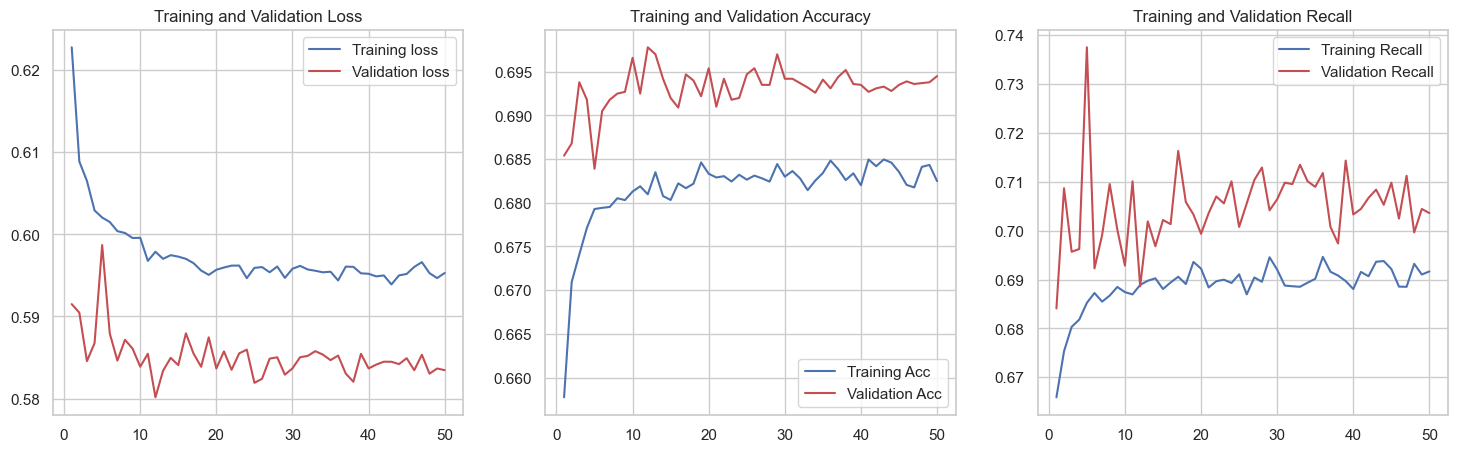

In [7]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    recall = history.history['recall']
    val_recall = history.history['val_recall']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(18, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Recall
    plt.subplot(1, 3, 3)
    plt.plot(epochs, recall, 'b', label='Training Recall')
    plt.plot(epochs, val_recall, 'r', label='Validation Recall')
    plt.title('Training and Validation Recall')
    plt.legend()

    plt.show()

plot_history(history)

## 6. Финална Оценка на Тестови Данни

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Neural Network Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.69      0.75      6464
           1       0.56      0.70      0.62      3536

    accuracy                           0.70     10000
   macro avg       0.68      0.70      0.68     10000
weighted avg       0.72      0.70      0.70     10000

ROC-AUC Score: 0.7656


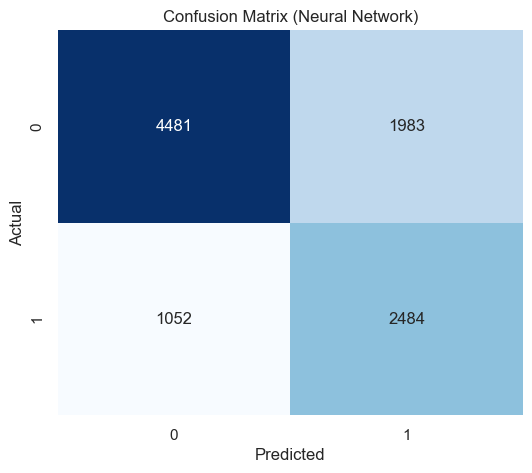

In [8]:
# Предсказания (вероятности)
y_pred_proba = model.predict(X_test)

# Превръщаме вероятностите в класове (0 или 1) с праг 0.5
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n--- Neural Network Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Матрица на объркването
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Neural Network)')
plt.show()

## 7. Запазване на Модела
Запазваме модела в keras формат за бъдеща употреба.

In [9]:
model.save('neural_network_model_updated_dataset.keras')
print("Моделът е запазен като 'neural_network_model_updated_dataset.keras'")

Моделът е запазен като 'neural_network_model_updated_dataset.keras'
